# GSCDB Dataset Analysis

This notebook analyzes computational chemistry functional performance across the GSCDB benchmark database. The analysis includes:

- Processing reaction energies from molecular energies
- Converting finite difference data to physical properties (dipoles, polarizabilities, frequencies)
- Computing error metrics (RMSE, MAE, relative errors) for different functionals
- Statistical analysis across different property types

**Input requirement:** `Molecule_Energies.csv` file containing:
- **Column names:** Different computational methods/functionals
- **Row names:** Individual molecules required in GSCDB

**Output Files Generated:**
1. **Reaction_Energies.csv**: Processed reaction energies from molecular data
2. **Results_values.csv** and **Results_errors.csv**: Complete values and errors in the common units for all functionals
3. **Errors_per_set_metric.csv** and so on: Error metrics (RMSE, MAE, MSE, specialized metrics) by dataset
4. **Relative_metric_per_set.csv**: Normalized errors for cross-dataset comparison
5. **Statistical_errors.csv**: Final functional performance ranking

Note that these output files are provided as illustrative examples only. Most functionals included here do not incorporate dispersion corrections, and therefore the resulting performance is not directly comparable to the results reported in the paper.

## Import Libraries and Setup

Import required libraries and configure pandas display options for better output visualization.

In [4]:
# Data analysis libraries
import pandas as pd
import numpy as np
from tqdm import tqdm

# Configure pandas display options for better visualization
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 5000)

## Step 1: Load Data and Calculate Reaction Energies

The following section processes stoichiometric data to calculate reaction energies from individual molecular energies.

In [5]:
# Load dataset information and molecular energies
df_func = pd.read_csv("../Info/DatasetEval.csv", header=0, index_col=0)
df_func = df_func[~df_func["Dataset"].isin(["SC74", "OEEFD"])]
df_energies = pd.read_csv("Molecule_Energies.csv", index_col=0, header=0)
funcs = df_energies.columns.tolist()

# Convert reference energies from Hartree to kcal/mol
df_func["Reference"] *= 627.50947406     

# Calculate reaction energies for each functional
print("Calculating reaction energies...")
for idx, row in tqdm(df_func.iterrows()):
    reactions = row["Stoichiometry"].split(",")  # Parse stoichiometry string
    ref_energy = row["Reference"]
    num_species = len(reactions) // 2  # Each species has coefficient and name
    
    for func in funcs:
        reac_energy = 0
        error = False
        
        # Sum up contributions from all species in the reaction
        for i in range(num_species):
            stoi = float(reactions[2*i])      # Stoichiometric coefficient
            specy = reactions[2*i+1]          # Species name
            energy = df_energies.loc[specy, func]
            reac_energy += stoi * energy
            
        if error:
            continue
        
        # Convert reaction energy from Hartree to kcal/mol
        df_func.at[idx, func] = reac_energy * 627.50947406

# Clean up dataframe by removing stoichiometry column
df_func.drop(columns=["Stoichiometry"], inplace=True)
print("Available functionals:", df_func.columns.tolist())

Calculating reaction energies...


8377it [00:11, 739.61it/s]

Available functionals: ['Dataset', 'Reference', 'wB97M2', 'B3LYP', 'BMK', 'CAMB3LYP', 'CF22D', 'M052X', 'M062X', 'M08HX', 'MN15', 'PBE0', 'PW6B95', 'SOGGA11X', 'r2SCAN0', 'wB97M-V', 'wB97X-V', 'revDSD-PBEP86-D4']


## Step 2: Data Validation and Quality Control

Check for missing data (NaN values) and ensure we only analyze datasets with complete functional coverage.

In [6]:
# Check for NaN or None values by dataset and functional
incomplete_datasets = []

for dataset, df_dataset in df_func.groupby("Dataset"):
    empty_funcs = []
    
    # Check each functional column for NaN/None values
    for func in funcs:
        nan_count = df_dataset[func].isnull().sum()
        if nan_count > 0:
            empty_funcs.append(func)
    
    if empty_funcs:
        print(f"Dataset '{dataset}' has NaN values in functionals: {', '.join(empty_funcs)}")
        incomplete_datasets.append(dataset)

print(f"Incomplete datasets: {incomplete_datasets}")

# Filter to remove datasets with incomplete data
df_func = df_func[~df_func["Dataset"].isin(incomplete_datasets)]

# Save processed reaction energies
print(f"Saved reaction energies for {len(df_func)} data points")
df_func.to_csv("Reaction_Energies.csv", index=True, header=True)


Incomplete datasets: []
Saved reaction energies for 8377 data points


## Step 3: Unit Conversion Functions

Define functions to convert finite difference energies to physical properties:
- **Dipole moments**: From energy differences to Debye units
- **Polarizabilities**: From energy differences to Å³ units  
- **Vibrational frequencies**: From force constants to cm⁻¹ units

Data conversion is performed for specific datasets:
- **Dip146**: Dipole moments (step size: 0.0001)
- **Pol130**: Polarizabilities (variable step sizes from FD_stepsize.csv)
- **HR46, T144**: Polarizabilities (step size: 0.004)
- **V30**: Vibrational frequencies (variable step sizes from FD_stepsize.csv)

In [7]:
def convert_to_dipole(energy, step_size=0.0001, input_in_kcal=True, output_in_debye=True):
    """
    Convert finite difference energy to dipole moment.
    
    Parameters:
    -----------
    energy : float
        Energy difference from finite difference calculation
    step_size : float, default=0.0001
        Step size used in finite difference calculation
    input_in_kcal : bool, default=True
        Whether input energy is in kcal/mol (vs Hartree)
    output_in_debye : bool, default=True
        Whether to output in Debye units (vs atomic units)
    
    Returns:
    --------
    float : Dipole moment in specified units
    """
    au_to_debye = 2.541746
    output = energy
    
    if input_in_kcal:
        output /= 627.50947406  # Convert kcal/mol to Hartree
    
    output /= 2 * step_size  # Convert to dipole moment in atomic units
    
    if output_in_debye:
        output *= au_to_debye  # Convert to Debye
    
    return output


def convert_to_polarizability(energy, step_size=0.01, input_in_kcal=True, output_in_A3=True):
    """
    Convert finite difference energy to polarizability.
    
    Parameters:
    -----------
    energy : float
        Energy difference from finite difference calculation
    step_size : float, default=0.01
        Step size used in finite difference calculation
    input_in_kcal : bool, default=True
        Whether input energy is in kcal/mol (vs Hartree)
    output_in_A3 : bool, default=True
        Whether to output in Å³ (vs atomic units)
    
    Returns:
    --------
    float : Polarizability in specified units
    """
    au_to_bohr3 = 0.529177 ** 3  # Conversion factor from atomic units to Bohr³
    output = energy
    
    if input_in_kcal:
        output /= 627.50947406  # Convert kcal/mol to Hartree
    
    output /= step_size**2  # Convert to polarizability in atomic units
    
    if output_in_A3:
        output *= au_to_bohr3  # Convert to Å³
    
    return output


def convert_to_frequency(energy, step_size=0.01, input_in_kcal=True, output_in_cm=True):
    """
    Convert finite difference energy to vibrational frequency.
    
    Parameters:
    -----------
    energy : float
        Energy difference from finite difference calculation (force constant)
    step_size : float, default=0.01
        Step size used in finite difference calculation
    input_in_kcal : bool, default=True
        Whether input energy is in kcal/mol (vs Hartree)
    output_in_cm : bool, default=True
        Whether to output in cm⁻¹ (vs atomic units)
    
    Returns:
    --------
    float : Frequency in specified units (preserves sign for imaginary frequencies)
    """
    constant_cm_to_hartree = 4.55633528e-6
    convert_force_constant_to_au = 1 / (1.66053907e-27/9.10938370e-31 * (1/0.529177211)**2)
    
    fc = energy
    if input_in_kcal:
        fc /= 627.50947406  # Convert kcal/mol to Hartree
    
    signature = np.sign(fc)  # Preserve sign for imaginary frequencies
    fc = np.abs(fc)  # Take absolute value for frequency calculation
    fc /= step_size**2  # Calculate force constant in Hartree/Å²
    fc *= convert_force_constant_to_au  # Convert to atomic units
    freq = np.sqrt(fc)  # Calculate frequency in atomic units
    
    if output_in_cm:
        freq /= constant_cm_to_hartree  # Convert to cm⁻¹
    
    freq *= signature  # Restore sign
    return freq

In [8]:
# Load processed reaction energies and step size information
df_func = pd.read_csv("Reaction_Energies.csv", index_col=0, header=0)
df_stepsizes = pd.read_csv("../Info/FD_stepsize.csv", header=0, index_col=0)

# Get all functional columns (skip "Dataset" but also process "Reference")
funcs = df_func.columns[1:]

# Convert Dip146 dataset: Energy differences → Dipole moments (Debye)
print("Converting Dip146 to dipole moments...")
dip146_index = df_func.index[df_func["Dataset"] == "Dip146"].to_list()
for idx in dip146_index:
    for func in funcs:
        df_func.at[idx, func] = convert_to_dipole(
            df_func.at[idx, func], step_size=0.0001, 
            input_in_kcal=True, output_in_debye=True)

# Convert Pol130 dataset: Energy differences → Polarizabilities (Å³)
print("Converting Pol130 to polarizabilities...")
pol130_index = df_func.index[df_func["Dataset"] == "Pol130"].to_list()
for idx in pol130_index:
    step_size = df_stepsizes.at[idx, "fd step"]
    for func in funcs:
        df_func.at[idx, func] = convert_to_polarizability(
            df_func.at[idx, func], step_size=step_size,
            input_in_kcal=True, output_in_A3=True)

# Convert HR46 and T144 datasets: Energy differences → Polarizabilities (Å³)
print("Converting HR46 and T144 to polarizabilities...")
hr46_and_t144_index = df_func.index[df_func["Dataset"].isin(["HR46", "T144"])].to_list()
for idx in hr46_and_t144_index:
    for func in funcs:
        df_func.at[idx, func] = convert_to_polarizability(
            df_func.at[idx, func], step_size=0.004,
            input_in_kcal=True, output_in_A3=True)

# Convert V30 dataset: Force constants → Vibrational frequencies (cm⁻¹)
print("Converting V30 to vibrational frequencies...")
v30_index = df_func.index[df_func["Dataset"] == "V30"].to_list()
for idx in v30_index:
    step_size = df_stepsizes.at[idx, "fd step"]
    for func in funcs:
        df_func.at[idx, func] = convert_to_frequency(
            df_func.at[idx, func], step_size=step_size,
            input_in_kcal=True, output_in_cm=True)


Converting Dip146 to dipole moments...
Converting Pol130 to polarizabilities...
Converting HR46 and T144 to polarizabilities...
Converting V30 to vibrational frequencies...


## Step 4: Save Results

In [9]:
# Calculate absolute errors for each functional
df_errors = df_func.copy()

# Compute errors as (calculated - reference) for functional columns
for func in df_errors.columns[2:]:  # Skip "Dataset" and "Reference" columns
    df_errors[func] = df_func[func] - df_func["Reference"]

# Save both values and errors to CSV file
print("Saving results to Results*.csv...")
df_func.to_csv("Results_values.csv", index=True)
df_errors.to_csv("Results_errors.csv", index=True)


Saving results to Results*.csv...


## Step 5: Calculate Errors

Compute root-mean-square error (RMSE), mean absolute error (MAE), mean signed error (MSE), and our metric errors (defined in the benchmark paper) for each functional.

In [10]:
# Load error data and supporting information
df_error = pd.read_csv("Results_errors.csv", index_col=0, header=0)
TMC34_weight = pd.read_csv("../Info/DatasetEval_TMC34_weight.csv", index_col=0, header=0)
O24x5_weight = pd.read_csv("../Info/DatasetEval_O24x5_weight.csv", index_col=0, header=0)
df_dataset_info = pd.read_csv("../Info/Datasets.csv", header=0, index_col=0)

# Get list of functionals (exclude Reference and Dataset columns)
funcs = df_error.columns.tolist()
funcs.remove("Reference")
funcs.remove("Dataset")

# Initialize dictionaries to store different error metrics
df_rmse_sets = {}
df_mae_sets = {}
df_mse_sets = {}
df_metric_set = {}

print("Calculating error metrics by dataset...")

# Calculate error metrics for each dataset
for dataset, df_dataset in df_error.groupby("Dataset"):
    # Initialize dataset entries with datatype information
    datatype = df_dataset_info.loc[dataset, "Datatype"]
    df_rmse_sets[dataset] = {"Datatype": datatype}
    df_mae_sets[dataset] = {"Datatype": datatype}
    df_metric_set[dataset] = {"Datatype": datatype}
    df_mse_sets[dataset] = {"Datatype": datatype}
    
    # Calculate standard error metrics for each functional
    for func in funcs:
        if func in df_error.columns:
            df_rmse_sets[dataset][func] = np.sqrt(np.mean(df_dataset[func]**2))  # Root Mean Square Error
            df_mae_sets[dataset][func] = np.mean(np.abs(df_dataset[func]))       # Mean Absolute Error
            df_mse_sets[dataset][func] = np.mean(df_dataset[func])               # Mean Signed Error
            df_metric_set[dataset][func] = df_mae_sets[dataset][func]            # Default metric is MAE
    
    # Apply specialized metrics for specific datasets
    # Mean Absolute Relative Error for polarizability and field-dependent datasets
    if dataset in ["Pol130", "HR46", "T144", "OEEF"]:
        for func in funcs:
            if func in df_error.columns:
                df_metric_set[dataset][func] = np.mean(np.abs(df_dataset[func] / df_dataset["Reference"]))
    
    # Weighted error for TMC datasets
    if dataset in ["TMD10", "MOR13", "TMB11"]:
        weight = TMC34_weight.loc[TMC34_weight["Dataset"] == dataset, "Weight"].values
        for func in funcs:
            if func in df_error.columns:
                weighted_errors = np.abs(df_dataset[func]) * weight[:-1]
                df_metric_set[dataset][func] = np.sum(weighted_errors) + weight[-1]
    
    # Weighted error for O24x5 datasets
    if dataset in ["O24", "O24x4"]: # calculate weighted absolute error
        weight = O24x5_weight.loc[O24x5_weight["Dataset"] == dataset, "Weight"].values
        for func in funcs:
            if func in df_error.columns:
                weighted_errors = np.abs(df_dataset[func]) * weight
                df_metric_set[dataset][func] = np.sum(weighted_errors)

    # Regularized MAE for dipole moments (normalized by max(|reference|, 1))
    if dataset == "Dip146":
        for func in funcs:
            if func in df_error.columns:
                df_metric_set[dataset][func] = np.mean(
                    np.abs(df_dataset[func] / np.maximum(np.abs(df_dataset["Reference"]), 1))
                )

# Convert dictionaries to DataFrames and sort by datatype and dataset name
df_rmse_sets = pd.DataFrame(df_rmse_sets).T
df_rmse_sets.index.name = "Dataset"
df_rmse_sets = df_rmse_sets.sort_values(by=["Datatype", "Dataset"])

df_mae_sets = pd.DataFrame(df_mae_sets).T
df_mae_sets.index.name = "Dataset"
df_mae_sets = df_mae_sets.sort_values(by=["Datatype", "Dataset"])

df_metric_set = pd.DataFrame(df_metric_set).T
df_metric_set.index.name = "Dataset"
df_metric_set = df_metric_set.sort_values(by=["Datatype", "Dataset"])

df_mse_sets = pd.DataFrame(df_mse_sets).T
df_mse_sets.index.name = "Dataset"
df_mse_sets = df_mse_sets.sort_values(by=["Datatype", "Dataset"])

# Save all error metrics to CSV files
print("Saving error metrics to Errors_per_set*.csv...")
df_rmse_sets.to_csv("Errors_per_set_RMSE.csv", index=True)
df_mae_sets.to_csv("Errors_per_set_MAE.csv", index=True)
df_metric_set.to_csv("Errors_per_set_Metric.csv", index=True)
df_mse_sets.to_csv("Errors_per_set_MSE.csv", index=True)

Calculating error metrics by dataset...
Saving error metrics to Errors_per_set*.csv...


## Step 6: Statistical Analysis by Dataset

To establish a robust baseline for comparison, we define a “standard error” for each data set as the average of the second, third, and fourth lowest errors among all tested hybrid functionals, stored in `../Info/Standard_errors.csv`.

Then we calculate normalized error ratio (NER), defined as the ratio between its error and the standard error for a given data set.

In [11]:
# Load metric data and standard reference errors
df_metric_set = pd.read_csv("Errors_per_set_Metric.csv", index_col=0, header=0)
df_standard = pd.read_csv("../Info/Standard_errors.csv", index_col=0, header=0)
standard_metric = df_standard["Metric"]

# Calculate relative errors by normalizing against standard reference values
df_errors_rel = df_metric_set.copy()

print("Calculating relative errors...")
for func in df_metric_set.columns:
    if func == "Datatype":
        continue
    if func in df_metric_set.columns:
        # Normalize each functional's errors by the corresponding standard error
        df_errors_rel[func] = df_metric_set[func] / standard_metric

# Save relative errors
df_errors_rel.to_csv("Relative_metric_per_set.csv", index=True, header=True)
print("Saved relative errors for cross-dataset comparison")

Calculating relative errors...
Saved relative errors for cross-dataset comparison


## Step 7: Generate Final Statistical Summary

Create overall performance rankings by calculating mean relative errors across all datasets and by property type. Functionals are ranked by overall performance.

In [12]:
# Load relative errors for final analysis
df_errors_rel = pd.read_csv("Relative_metric_per_set.csv", index_col=0, header=0)

# Initialize summary statistics DataFrame
df_errors = pd.DataFrame(columns=funcs)

# Calculate overall mean relative error across all datasets
df_errors.loc["Mean"] = df_errors_rel[funcs].mean(axis=0)

# Calculate mean relative error by property type (datatype)
print("Calculating statistics by property type...")
for datatype, df_errors_set_datatype in df_errors_rel.groupby("Datatype"):
    df_errors_set_datatype = df_errors_set_datatype.drop(columns=["Datatype"])
    df_errors.loc[f"Mean {datatype}"] = df_errors_set_datatype.mean(axis=0)

# Sort functionals by overall performance (ascending mean error)
sorted_funcs = sorted(funcs, key=lambda x: df_errors.loc["Mean", x])
df_errors = df_errors[sorted_funcs]

# Save final statistical summary
df_errors.to_csv("Statistical_errors.csv", index=True, header=True)

print("Analysis complete! Files generated:")
print("- Reaction_Energies.csv: Processed reaction energies")
print("- Results*.csv: Values and errors for all functionals")
print("- Errors_per_set*.csv: Error metrics by dataset")
print("- Relative_metric_per_set.csv: Normalized relative errors")
print("- Statistical_errors.csv: Final performance ranking")

# Display top 5 performing functionals
print("\nTop 5 performing functionals (lowest mean relative error):")
for i, func in enumerate(sorted_funcs[:5], 1):
    mean_error = df_errors.loc["Mean", func]
    print(f"{i}. {func}: {mean_error:.3f}")

Calculating statistics by property type...
Analysis complete! Files generated:
- Reaction_Energies.csv: Processed reaction energies
- Results*.csv: Values and errors for all functionals
- Errors_per_set*.csv: Error metrics by dataset
- Relative_metric_per_set.csv: Normalized relative errors
- Statistical_errors.csv: Final performance ranking

Top 5 performing functionals (lowest mean relative error):
1. wB97M2: 0.949
2. wB97M-V: 1.076
3. CF22D: 1.249
4. wB97X-V: 1.313
5. revDSD-PBEP86-D4: 1.522


# Plotting Results

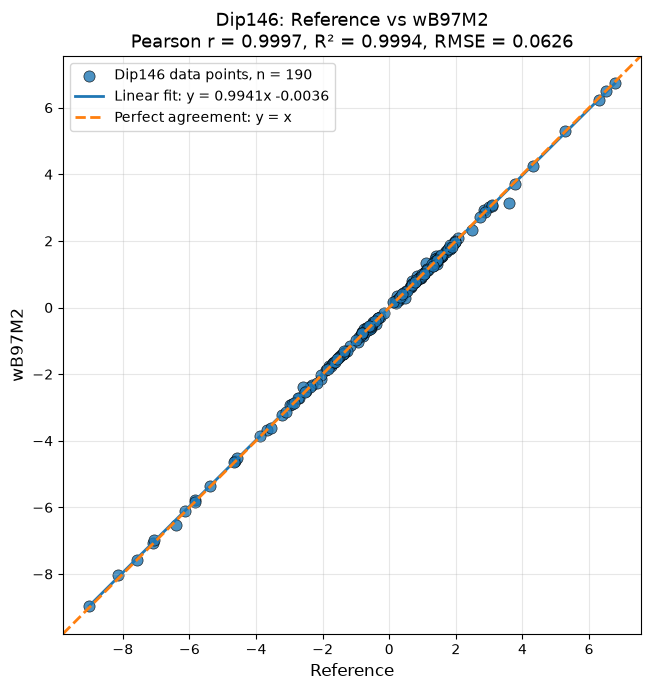

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Results_values.csv")

def plot_reference_vs_functional(
    df,
    dataset_value,
    y_col,
    x_col="Reference",
    dataset_col="Dataset",
    reaction_col="Reaction"
):
    # Select selected dataset rows
    selected_data = df[df[dataset_col] == dataset_value].copy()

    # Select useful columns
    output_columns = [dataset_col, x_col, y_col]

    # Define x and y values
    x = selected_data[x_col].to_numpy()
    y = selected_data[y_col].to_numpy()

     # Calculate errors
    selected_data["Error"] = selected_data[y_col] - selected_data[x_col]
    selected_data["Absolute_Error"] = np.abs(selected_data["Error"])
    selected_data["Squared_Error"] = selected_data["Error"] ** 2

    # Calculate RMSE, Pearson r, regression line, and R-squared
    rmse = np.sqrt(np.mean(selected_data["Squared_Error"]))
    pearson_r = np.corrcoef(x, y)[0, 1]

    slope, intercept = np.polyfit(x, y, 1)
    predicted_y = slope * x + intercept

    ss_residual = np.sum((y - predicted_y) ** 2)
    ss_total = np.sum((y - np.mean(y)) ** 2)
    r_squared = 1 - (ss_residual / ss_total)

    # Prepare regression line and plot limits
    sort_order = np.argsort(x)
    x_sorted = x[sort_order]
    predicted_y_sorted = slope * x_sorted + intercept

    minimum_value = min(x.min(), y.min())
    maximum_value = max(x.max(), y.max())
    value_range = maximum_value - minimum_value

    padding = 0.05 * value_range if value_range > 0 else 1.0
    plot_minimum = minimum_value - padding
    plot_maximum = maximum_value + padding

    # Generate correlation plot
    plt.figure(figsize=(8, 7))

    plt.scatter(
        x,
        y,
        s=65,
        alpha=0.8,
        edgecolors="black",
        linewidths=0.5,
        label=f"{dataset_value} data points, n = {len(selected_data)}"
    )

    plt.plot(
        x_sorted,
        predicted_y_sorted,
        linewidth=2,
        label=f"Linear fit: y = {slope:.4f}x {intercept:+.4f}"
    )

    plt.plot(
        [plot_minimum, plot_maximum],
        [plot_minimum, plot_maximum],
        linestyle="--",
        linewidth=2,
        label="Perfect agreement: y = x"
    )

    plt.xlim(plot_minimum, plot_maximum)
    plt.ylim(plot_minimum, plot_maximum)
    plt.gca().set_aspect("equal", adjustable="box")

    plt.xlabel(x_col, fontsize=12)
    plt.ylabel(y_col, fontsize=12)

    plt.title(
        f"{dataset_value}: {x_col} vs {y_col}\n"
        f"Pearson r = {pearson_r:.4f}, "
        f"R² = {r_squared:.4f}, "
        f"RMSE = {rmse:.4f}",
        fontsize=13
    )

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    results = {
        "dataset": dataset_value,
        "x_column": x_col,
        "y_column": y_col,
        "n_points": len(selected_data),
        "rmse": rmse,
        "pearson_r": pearson_r,
        "r_squared": r_squared,
        "slope": slope,
        "intercept": intercept
    }

    return results, selected_data

results, Dip146_wB97M2_data = plot_reference_vs_functional(
    df=df,
    dataset_value="Dip146",
    y_col="wB97M2"
)

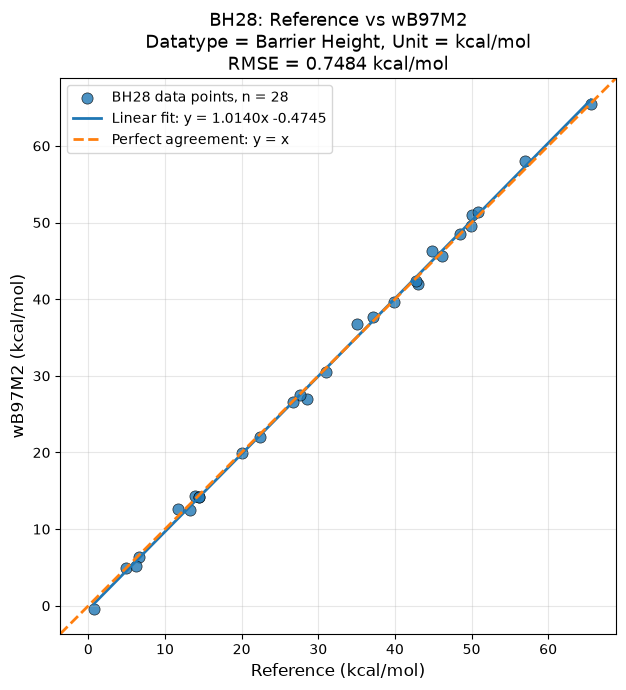

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Results_values.csv")
df_dataset_info = pd.read_csv("..\Info\Datasets.csv")


def get_dataset_info(dataset_value, df_dataset_info):
    dataset_row = df_dataset_info[df_dataset_info["Name"] == dataset_value]

    if dataset_row.empty:
        datatype = "Unknown"
        description = "No description found"
    else:
        datatype = dataset_row["Datatype"].iloc[0]
        description = dataset_row["Description"].iloc[0]

    return datatype, description


def get_reference_unit(dataset_value):
    raw_unit = "kcal/mol"

    converted_units_from_notebook = {
        "Dip146": "Debye",
        "Pol130": "Å³",
        "HR46": "Å³",
        "T144": "Å³",
        "V30": "cm⁻¹"
    }

    converted_unit = converted_units_from_notebook.get(dataset_value, raw_unit)

    return raw_unit, converted_unit

def plot_reference_vs_functional(
    df,
    df_dataset_info,
    dataset_value,
    y_col,
    x_col="Reference",
    dataset_col="Dataset"
):
    selected_data = df[df[dataset_col] == dataset_value].copy()

    datatype, description = get_dataset_info(dataset_value, df_dataset_info)
    raw_unit, converted_unit = get_reference_unit(dataset_value)

    x = selected_data[x_col].to_numpy()
    y = selected_data[y_col].to_numpy()

    selected_data["Error"] = selected_data[y_col] - selected_data[x_col]
    selected_data["Absolute_Error"] = np.abs(selected_data["Error"])
    selected_data["Squared_Error"] = selected_data["Error"] ** 2

    rmse = np.sqrt(np.mean(selected_data["Squared_Error"]))
    pearson_r = np.corrcoef(x, y)[0, 1]

    slope, intercept = np.polyfit(x, y, 1)
    predicted_y = slope * x + intercept

    ss_residual = np.sum((y - predicted_y) ** 2)
    ss_total = np.sum((y - np.mean(y)) ** 2)
    r_squared = 1 - (ss_residual / ss_total)

    sort_order = np.argsort(x)
    x_sorted = x[sort_order]
    predicted_y_sorted = slope * x_sorted + intercept

    minimum_value = min(x.min(), y.min())
    maximum_value = max(x.max(), y.max())
    value_range = maximum_value - minimum_value

    padding = 0.05 * value_range if value_range > 0 else 1.0
    plot_minimum = minimum_value - padding
    plot_maximum = maximum_value + padding

    plt.figure(figsize=(8, 7))

    plt.scatter(
        x,
        y,
        s=65,
        alpha=0.8,
        edgecolors="black",
        linewidths=0.5,
        label=f"{dataset_value} data points, n = {len(selected_data)}"
    )

    plt.plot(
        x_sorted,
        predicted_y_sorted,
        linewidth=2,
        label=f"Linear fit: y = {slope:.4f}x {intercept:+.4f}"
    )

    plt.plot(
        [plot_minimum, plot_maximum],
        [plot_minimum, plot_maximum],
        linestyle="--",
        linewidth=2,
        label="Perfect agreement: y = x"
    )

    plt.xlim(plot_minimum, plot_maximum)
    plt.ylim(plot_minimum, plot_maximum)
    plt.gca().set_aspect("equal", adjustable="box")

    plt.xlabel(f"{x_col} ({raw_unit})", fontsize=12)
    plt.ylabel(f"{y_col} ({raw_unit})", fontsize=12)

    plt.title(
        f"{dataset_value}: {x_col} vs {y_col}\n"
        f"Datatype = {datatype}, Unit = {raw_unit}\n"
        f"RMSE = {rmse:.4f} {raw_unit}",
        fontsize=13
    )

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    results = {
        "dataset": dataset_value,
        "datatype": datatype,
        "description": description,
        "raw_unit": raw_unit,
        "converted_unit_from_notebook": converted_unit,
        "x_column": x_col,
        "y_column": y_col,
        "n_points": len(selected_data),
        "rmse": rmse,
        "pearson_r": pearson_r,
        "r_squared": r_squared,
        "slope": slope,
        "intercept": intercept
    }

    return results, selected_data

results, BH28_wB97M2_data = plot_reference_vs_functional(
    df=df,
    df_dataset_info=df_dataset_info,
    dataset_value="BH28",
    y_col="wB97M2"
)

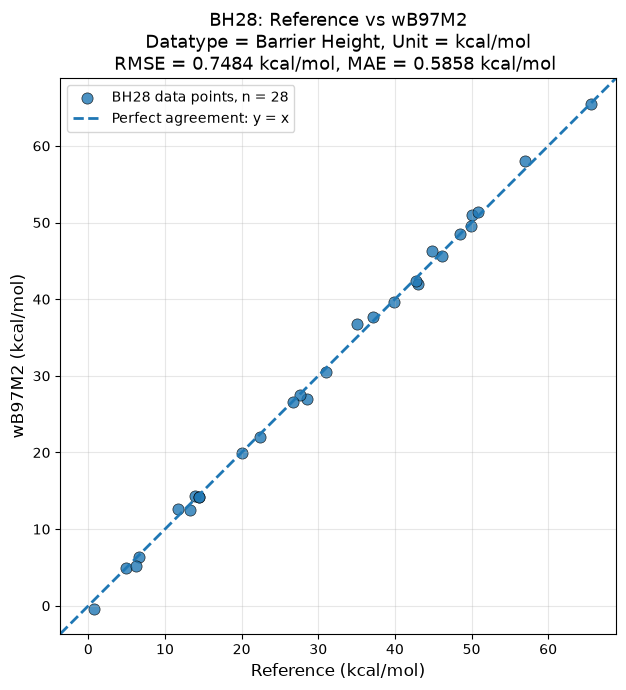

{'dataset': 'BH28', 'datatype': 'Barrier Height', 'description': 'Highly accurate subset chosen from BHPERI, CRBH20, BHDIV10, and PX13 sets', 'raw_unit': 'kcal/mol', 'converted_unit_from_notebook': 'kcal/mol', 'x_column': 'Reference', 'y_column': 'wB97M2', 'n_points': 28, 'rmse': np.float64(0.7483956819356008), 'mae': np.float64(0.5857980990748344), 'pearson_r': np.float64(0.9992210862584151)}


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("Results_values.csv")

df_dataset_info = pd.read_csv(r"..\Info\Datasets.csv")


def get_dataset_info(dataset_value, df_dataset_info):
    dataset_row = df_dataset_info[
        df_dataset_info["Name"] == dataset_value
    ]

    if dataset_row.empty:
        datatype = "Unknown"
        description = "No description found"
    else:
        datatype = dataset_row["Datatype"].iloc[0]
        description = dataset_row["Description"].iloc[0]

    return datatype, description


def get_reference_unit(dataset_value):
    raw_unit = "kcal/mol"

    converted_units_from_notebook = {
        "Dip146": "Debye",
        "Pol130": "Å³",
        "HR46": "Å³",
        "T144": "Å³",
        "V30": "cm⁻¹"
    }

    converted_unit = converted_units_from_notebook.get(
        dataset_value,
        raw_unit
    )

    return raw_unit, converted_unit

def plot_reference_vs_functional(
    df,
    df_dataset_info,
    dataset_value,
    y_col,
    x_col="Reference",
    dataset_col="Dataset"
):
    
    required_columns = [
        dataset_col,
        x_col,
        y_col
    ]


    df_temp = df.copy()

    df_temp[dataset_col] = (
        df_temp[dataset_col]
        .astype(str)
        .str.strip()
    )

    selected_data = df_temp[
        df_temp[dataset_col] == dataset_value
    ].copy()

    if selected_data.empty:
        raise ValueError(
            f"No rows found for Dataset = '{dataset_value}'."
        )

    datatype, description = get_dataset_info(
        dataset_value,
        df_dataset_info
    )

    raw_unit, converted_unit = get_reference_unit(dataset_value)

    x = selected_data[x_col].to_numpy()
    y = selected_data[y_col].to_numpy()

    selected_data["Error"] = (
        selected_data[y_col] - selected_data[x_col]
    )

    selected_data["Absolute_Error"] = np.abs(
        selected_data["Error"]
    )

    selected_data["Squared_Error"] = (
        selected_data["Error"] ** 2
    )


    rmse = np.sqrt(
        np.mean(selected_data["Squared_Error"])
    )

    mae = np.mean(
        selected_data["Absolute_Error"]
    )


    pearson_r = np.corrcoef(x, y)[0, 1]


    minimum_value = min(
        x.min(),
        y.min()
    )

    maximum_value = max(
        x.max(),
        y.max()
    )

    value_range = maximum_value - minimum_value

    padding = (
        0.05 * value_range
        if value_range > 0
        else 1.0
    )

    plot_minimum = minimum_value - padding
    plot_maximum = maximum_value + padding


    plt.figure(figsize=(8, 7))

    # Scatter plot
    plt.scatter(
        x,
        y,
        s=65,
        alpha=0.8,
        edgecolors="black",
        linewidths=0.5,
        label=f"{dataset_value} data points, n = {len(selected_data)}"
    )

    plt.plot(
        [plot_minimum, plot_maximum],
        [plot_minimum, plot_maximum],
        linestyle="--",
        linewidth=2,
        label="Perfect agreement: y = x"
    )

    plt.xlim(plot_minimum, plot_maximum)
    plt.ylim(plot_minimum, plot_maximum)

    plt.gca().set_aspect(
        "equal",
        adjustable="box"
    )

    plt.xlabel(
        f"{x_col} ({raw_unit})",
        fontsize=12
    )

    plt.ylabel(
        f"{y_col} ({raw_unit})",
        fontsize=12
    )

    plt.title(
        f"{dataset_value}: {x_col} vs {y_col}\n"
        f"Datatype = {datatype}, Unit = {raw_unit}\n"
        f"RMSE = {rmse:.4f} {raw_unit}, "
        f"MAE = {mae:.4f} {raw_unit} ",
        fontsize=13
    )

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    results = {
        "dataset": dataset_value,
        "datatype": datatype,
        "description": description,
        "raw_unit": raw_unit,
        "converted_unit_from_notebook": converted_unit,
        "x_column": x_col,
        "y_column": y_col,
        "n_points": len(selected_data),
        "rmse": rmse,
        "mae": mae,
        "pearson_r": pearson_r
    }

    return results, selected_data


results, BH28_wB97M2_data = plot_reference_vs_functional(
    df=df,
    df_dataset_info=df_dataset_info,
    dataset_value="BH28",
    y_col="wB97M2"
)

print(results)

In [14]:
df_metric_set = pd.read_csv("Errors_per_set_Metric.csv")

df_standard_errors = pd.read_csv(
    r"..\Info\Standard_errors.csv"
)

df_relative_metric = pd.read_csv(
    "Relative_metric_per_set.csv"
)

In [15]:
def get_ner_values(
    dataset_value,
    functional,
    df_metric_set,
    df_standard_errors,
    df_relative_metric=None,
    rtol=1e-10,
    atol=1e-12,
):
    """
    Calculate the Normalized Error Ratio (NER) for one dataset
    and one functional.

    NER = metric error / standard metric error
    """

    metric_df = df_metric_set.copy()
    standard_df = df_standard_errors.copy()

    # Clean dataset names
    metric_df["Dataset"] = (
        metric_df["Dataset"]
        .astype(str)
        .str.strip()
    )

    standard_df["Dataset"] = (
        standard_df["Dataset"]
        .astype(str)
        .str.strip()
    )

    dataset_value = str(dataset_value).strip()

    # Check that the functional exists
    if functional not in metric_df.columns:
        raise KeyError(
            f"Functional '{functional}' was not found in "
            "Errors_per_set_Metric.csv."
        )

    # Select dataset rows
    metric_row = metric_df[
        metric_df["Dataset"] == dataset_value
    ]

    standard_row = standard_df[
        standard_df["Dataset"] == dataset_value
    ]

    if metric_row.empty:
        raise ValueError(
            f"Dataset '{dataset_value}' was not found in "
            "Errors_per_set_Metric.csv."
        )

    if standard_row.empty:
        raise ValueError(
            f"Dataset '{dataset_value}' was not found in "
            "Standard_errors.csv."
        )

    if len(metric_row) > 1:
        raise ValueError(
            f"Dataset '{dataset_value}' occurs more than once in "
            "Errors_per_set_Metric.csv."
        )

    if len(standard_row) > 1:
        raise ValueError(
            f"Dataset '{dataset_value}' occurs more than once in "
            "Standard_errors.csv."
        )

    # Functional's metric error for the selected dataset
    metric_error = float(
        metric_row[functional].iloc[0]
    )

    # Benchmark standard metric for the selected dataset
    standard_error = float(
        standard_row["Metric"].iloc[0]
    )

    if not np.isfinite(standard_error):
        raise ValueError(
            f"The standard error for '{dataset_value}' is not finite."
        )

    if standard_error == 0:
        raise ZeroDivisionError(
            f"The standard error for '{dataset_value}' is zero."
        )

    # Calculate NER
    ner_calculated = metric_error / standard_error

    # Default values when no reference relative-error file is supplied
    ner_from_file = np.nan
    ner_matches_file = None

    # Compare against Relative_metric_per_set.csv
    if df_relative_metric is not None:
        relative_df = df_relative_metric.copy()

        relative_df["Dataset"] = (
            relative_df["Dataset"]
            .astype(str)
            .str.strip()
        )

        if functional not in relative_df.columns:
            raise KeyError(
                f"Functional '{functional}' was not found in "
                "Relative_metric_per_set.csv."
            )

        relative_row = relative_df[
            relative_df["Dataset"] == dataset_value
        ]

        if relative_row.empty:
            raise ValueError(
                f"Dataset '{dataset_value}' was not found in "
                "Relative_metric_per_set.csv."
            )

        if len(relative_row) > 1:
            raise ValueError(
                f"Dataset '{dataset_value}' occurs more than once in "
                "Relative_metric_per_set.csv."
            )

        ner_from_file = float(
            relative_row[functional].iloc[0]
        )

        ner_matches_file = bool(
            np.isclose(
                ner_calculated,
                ner_from_file,
                rtol=rtol,
                atol=atol,
                equal_nan=True,
            )
        )

    return {
        "metric_error": metric_error,
        "standard_error": standard_error,
        "ner": ner_calculated,
        "ner_from_file": ner_from_file,
        "ner_matches_file": ner_matches_file,
    }

In [16]:
def plot_reference_vs_functional(
    df,
    df_dataset_info,
    df_metric_set,
    df_standard_errors,
    df_relative_metric,
    dataset_value,
    y_col,
    x_col="Reference",
    dataset_col="Dataset",
):
    required_columns = [
        dataset_col,
        x_col,
        y_col,
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in df.columns
    ]

    if missing_columns:
        raise KeyError(
            f"Missing columns in Results_values.csv: "
            f"{missing_columns}"
        )

    df_temp = df.copy()

    # Clean dataset names
    df_temp[dataset_col] = (
        df_temp[dataset_col]
        .astype(str)
        .str.strip()
    )

    dataset_value = str(dataset_value).strip()

    # Select the requested dataset
    selected_data = df_temp[
        df_temp[dataset_col] == dataset_value
    ].copy()

    if selected_data.empty:
        raise ValueError(
            f"No rows found for Dataset = '{dataset_value}'."
        )

    # Convert plotting columns to numeric
    selected_data[x_col] = pd.to_numeric(
        selected_data[x_col],
        errors="coerce",
    )

    selected_data[y_col] = pd.to_numeric(
        selected_data[y_col],
        errors="coerce",
    )

    # Remove rows where x or y is missing
    selected_data = selected_data.dropna(
        subset=[x_col, y_col]
    ).copy()

    if selected_data.empty:
        raise ValueError(
            f"No valid numeric values remain for "
            f"{x_col} and {y_col}."
        )

    datatype, description = get_dataset_info(
        dataset_value,
        df_dataset_info,
    )

    raw_unit, converted_unit = get_reference_unit(
        dataset_value
    )

    x = selected_data[x_col].to_numpy()
    y = selected_data[y_col].to_numpy()

    # Calculate individual errors
    selected_data["Error"] = (
        selected_data[y_col]
        - selected_data[x_col]
    )

    selected_data["Absolute_Error"] = np.abs(
        selected_data["Error"]
    )

    selected_data["Squared_Error"] = (
        selected_data["Error"] ** 2
    )

    # Ordinary RMSE and MAE from Results_values.csv
    rmse = np.sqrt(
        np.mean(selected_data["Squared_Error"])
    )

    mae = np.mean(
        selected_data["Absolute_Error"]
    )

    # Pearson correlation
    if len(selected_data) > 1:
        pearson_r = np.corrcoef(x, y)[0, 1]
    else:
        pearson_r = np.nan

    # Obtain the benchmark metric error and NER
    ner_results = get_ner_values(
        dataset_value=dataset_value,
        functional=y_col,
        df_metric_set=df_metric_set,
        df_standard_errors=df_standard_errors,
        df_relative_metric=df_relative_metric,
    )

    metric_error = ner_results["metric_error"]
    standard_error = ner_results["standard_error"]
    ner = ner_results["ner"]
    ner_from_file = ner_results["ner_from_file"]
    ner_matches_file = ner_results["ner_matches_file"]

    # Print NER information
    print(f"Dataset: {dataset_value}")
    print(f"Functional: {y_col}")
    print(f"Metric error: {metric_error:.10f}")
    print(f"Standard metric error: {standard_error:.10f}")
    print(f"Calculated NER: {ner:.10f}")
    print(
        "NER from Relative_metric_per_set.csv: "
        f"{ner_from_file:.10f}"
    )
    print(
        "Calculated NER matches relative-error file: "
        f"{ner_matches_file}"
    )

    # Determine equal x and y limits
    minimum_value = min(
        x.min(),
        y.min(),
    )

    maximum_value = max(
        x.max(),
        y.max(),
    )

    value_range = maximum_value - minimum_value

    padding = (
        0.05 * value_range
        if value_range > 0
        else 1.0
    )

    plot_minimum = minimum_value - padding
    plot_maximum = maximum_value + padding

    # Create plot
    plt.figure(figsize=(8, 7))

    plt.scatter(
        x,
        y,
        s=65,
        alpha=0.8,
        edgecolors="black",
        linewidths=0.5,
        label=(
            f"{dataset_value} data points, "
            f"n = {len(selected_data)}"
        ),
    )

    # Perfect-agreement line
    plt.plot(
        [plot_minimum, plot_maximum],
        [plot_minimum, plot_maximum],
        linestyle="--",
        linewidth=2,
        label="Perfect agreement: y = x",
    )

    plt.xlim(plot_minimum, plot_maximum)
    plt.ylim(plot_minimum, plot_maximum)

    plt.gca().set_aspect(
        "equal",
        adjustable="box",
    )

    plt.xlabel(
        f"{x_col} ({raw_unit})",
        fontsize=12,
    )

    plt.ylabel(
        f"{y_col} ({raw_unit})",
        fontsize=12,
    )

    plt.title(
        f"{dataset_value}: {x_col} vs {y_col}\n"
        f"Datatype = {datatype}, Unit = {raw_unit}\n"
        f"RMSE = {rmse:.4f}, MAE = {mae:.4f}, "
        f"Metric error = {metric_error:.4f}, "
        f"Standard error = {standard_error:.4f}, "
        f"NER = {ner:.4f}",
        fontsize=12,
    )

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    results = {
        "dataset": dataset_value,
        "datatype": datatype,
        "description": description,
        "raw_unit": raw_unit,
        "converted_unit_from_notebook": converted_unit,
        "x_column": x_col,
        "y_column": y_col,
        "n_points": len(selected_data),
        "rmse": rmse,
        "mae": mae,
        "pearson_r": pearson_r,
        "metric_error": metric_error,
        "standard_metric_error": standard_error,
        "ner": ner,
        "ner_from_relative_file": ner_from_file,
        "ner_matches_relative_file": ner_matches_file,
    }

    return results, selected_data

Dataset: HR46
Functional: wB97M2
Metric error: 0.0159982753
Standard metric error: 0.0126246381
Calculated NER: 1.2672264499
NER from Relative_metric_per_set.csv: 1.2672264499
Calculated NER matches relative-error file: True


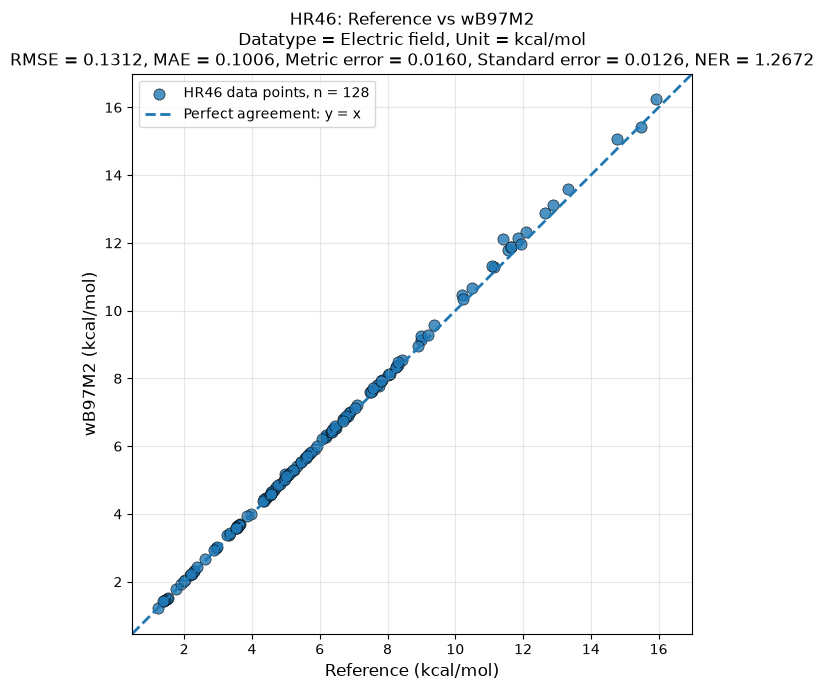


Complete results:
{'dataset': 'HR46', 'datatype': 'Electric field', 'description': 'Static polarizabilities (including individual components) for 46 systems at equilibrium', 'raw_unit': 'kcal/mol', 'converted_unit_from_notebook': 'Å³', 'x_column': 'Reference', 'y_column': 'wB97M2', 'n_points': 128, 'rmse': np.float64(0.1311784496099055), 'mae': np.float64(0.1005607600300778), 'pearson_r': np.float64(0.9997997410636043), 'metric_error': 0.0159982753078067, 'standard_metric_error': 0.0126246380902822, 'ner': 1.2672264498513706, 'ner_from_relative_file': 1.2672264498513706, 'ner_matches_relative_file': True}


In [18]:
results, HR46_wB97M2_data = plot_reference_vs_functional(
    df=df,
    df_dataset_info=df_dataset_info,
    df_metric_set=df_metric_set,
    df_standard_errors=df_standard_errors,
    df_relative_metric=df_relative_metric,
    dataset_value="HR46",
    y_col="wB97M2",
)

print("\nComplete results:")
print(results)

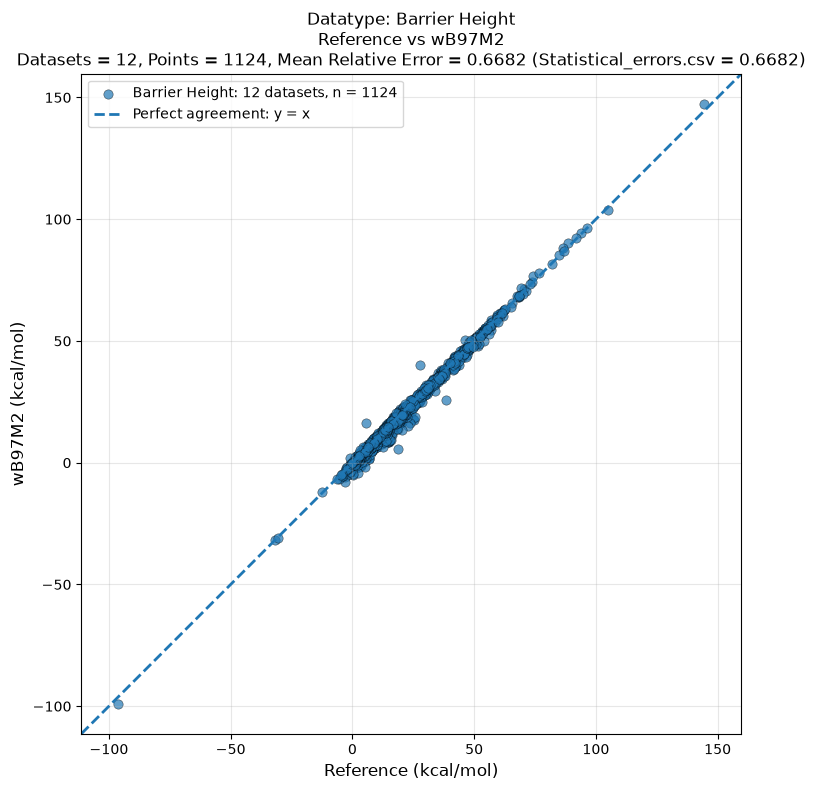


Returned summary dictionary:
datatype: Barrier Height
functional: wB97M2
number_of_datasets: 12
number_of_points: 1124
pooled_rmse: 1.8300229901617235
pooled_mae: 1.2214142729268302
pooled_pearson_r: 0.9962183933220173
mean_relative_error: 0.6682301509999484
mean_relative_error_from_statistical_file: 0.6682301509999484
mean_relative_error_absolute_difference: 0.0
mean_relative_error_matches: True
all_dataset_ner_values_match: True


In [24]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Files in the Analysis folder
RESULTS_FILE = "Results_values.csv"
ERRORS_PER_SET_METRIC_FILE = "Errors_per_set_Metric.csv"
RELATIVE_METRIC_FILE = "Relative_metric_per_set.csv"
STATISTICAL_ERRORS_FILE = "Statistical_errors.csv"

# Files in the Info folder
DATASET_INFO_FILE = r"..\Info\Datasets.csv"
STANDARD_ERRORS_FILE = r"..\Info\Standard_errors.csv"

# Select one complete datatype and one DFT functional
DATATYPE_VALUE = "Barrier Height"
FUNCTIONAL_NAME = "wB97M2"

# Plot columns in Results_values.csv
REFERENCE_COLUMN = "Reference"
DATASET_COLUMN = "Dataset"

# Optional outputs
SAVE_PLOT = False
PLOT_FILE = "Datatype_Reference_vs_Functional.png"

SAVE_NER_TABLE = False
NER_TABLE_FILE = "Datatype_dataset_NER_results.csv"

# Numerical comparison tolerances
RTOL = 1e-10
ATOL = 1e-12


# ============================================================
# 2. FILE LOADING AND CLEANING FUNCTIONS
# ============================================================

def load_csv(file_path, description, index_col=None):
    """Load a CSV file and raise a clear error if it is missing."""

    if not os.path.exists(file_path):
        raise FileNotFoundError(
            f"\nCould not find {description}:\n"
            f"{os.path.abspath(file_path)}\n"
            "Check the file path and the current working directory."
        )

    return pd.read_csv(file_path, index_col=index_col)


def clean_text_column(dataframe, column):
    """Return a copy with whitespace removed from a text column."""

    if column not in dataframe.columns:
        raise KeyError(
            f"Column '{column}' was not found. "
            f"Available columns: {dataframe.columns.tolist()}"
        )

    cleaned = dataframe.copy()
    cleaned[column] = cleaned[column].astype("string").str.strip()
    return cleaned


def get_axis_unit(datatype):
    """
    Return a suitable label for the pooled datatype correlation plot.

    Electric-field datasets can contain different physical properties,
    so the plot may contain dataset-specific units.
    """

    energy_datatypes = {
        "Barrier Height",
        "Intramolecular Noncovalent",
        "Isomerization",
        "Noncovalent",
        "Thermochemistry",
        "Transition Metal",
    }

    if datatype in energy_datatypes:
        return "kcal/mol"

    if datatype == "Frequency":
        return "cm⁻¹"

    return "dataset-specific units"


# ============================================================
# 3. DATATYPE ANALYSIS FUNCTION
# ============================================================

def plot_datatype_reference_vs_functional(
    df_results,
    df_dataset_info,
    df_metric_set,
    df_standard_errors,
    df_relative_metric,
    df_statistical_errors,
    datatype_value,
    functional_name,
    reference_column="Reference",
    dataset_column="Dataset",
    rtol=1e-10,
    atol=1e-12,
):
    """
    For one complete Datatype and one selected functional:

    1. Find all datasets belonging to the Datatype from Datasets.csv.
    2. Calculate every dataset's NER:

           NER = Metric error / Standard metric error

    3. Compare every calculated NER with Relative_metric_per_set.csv.
    4. Calculate the Datatype Mean Relative Error:

           MRE = arithmetic mean of dataset-level NER values

    5. Compare the calculated MRE with Statistical_errors.csv.
    6. Plot all Reference and functional values for the selected Datatype.
    """

    datatype_value = str(datatype_value).strip()
    functional_name = str(functional_name).strip()

    # --------------------------------------------------------
    # Clean identifying columns
    # --------------------------------------------------------

    results = clean_text_column(df_results, dataset_column)
    dataset_info = clean_text_column(df_dataset_info, "Name")
    metric_set = clean_text_column(df_metric_set, "Dataset")
    standard_errors = clean_text_column(
        df_standard_errors,
        "Dataset",
    )
    relative_metric = clean_text_column(
        df_relative_metric,
        "Dataset",
    )

    if "Datatype" not in dataset_info.columns:
        raise KeyError("Datasets.csv must contain a 'Datatype' column.")

    dataset_info["Datatype"] = (
        dataset_info["Datatype"]
        .astype("string")
        .str.strip()
    )

    if "Datatype" in metric_set.columns:
        metric_set["Datatype"] = (
            metric_set["Datatype"]
            .astype("string")
            .str.strip()
        )

    if "Datatype" in relative_metric.columns:
        relative_metric["Datatype"] = (
            relative_metric["Datatype"]
            .astype("string")
            .str.strip()
        )

    df_statistical_errors = df_statistical_errors.copy()
    df_statistical_errors.index = (
        df_statistical_errors.index.astype(str).str.strip()
    )

    # --------------------------------------------------------
    # Validate the selected datatype
    # --------------------------------------------------------

    available_datatypes = sorted(
        dataset_info["Datatype"].dropna().unique().tolist()
    )

    if datatype_value not in available_datatypes:
        raise ValueError(
            f"Datatype '{datatype_value}' was not found.\n"
            f"Available Datatypes: {available_datatypes}"
        )

    # Datasets.csv defines which datasets belong to the datatype
    datatype_datasets = (
        dataset_info.loc[
            dataset_info["Datatype"] == datatype_value,
            "Name",
        ]
        .dropna()
        .drop_duplicates()
        .tolist()
    )

    if not datatype_datasets:
        raise ValueError(
            f"No datasets were found for Datatype '{datatype_value}'."
        )

    # --------------------------------------------------------
    # Validate required functional and columns
    # --------------------------------------------------------

    required_result_columns = {
        dataset_column,
        reference_column,
        functional_name,
    }

    missing_result_columns = required_result_columns.difference(
        results.columns
    )

    if missing_result_columns:
        raise KeyError(
            "Missing columns in Results_values.csv: "
            f"{sorted(missing_result_columns)}"
        )

    for dataframe_name, dataframe in [
        ("Errors_per_set_Metric.csv", metric_set),
        ("Relative_metric_per_set.csv", relative_metric),
        ("Statistical_errors.csv", df_statistical_errors),
    ]:
        if functional_name not in dataframe.columns:
            raise KeyError(
                f"Functional '{functional_name}' was not found in "
                f"{dataframe_name}."
            )

    if "Metric" not in standard_errors.columns:
        raise KeyError(
            "Standard_errors.csv must contain a 'Metric' column."
        )

    # --------------------------------------------------------
    # Build the dataset-level NER table
    # --------------------------------------------------------

    datatype_metric = metric_set.loc[
        metric_set["Dataset"].isin(datatype_datasets),
        ["Dataset", functional_name],
    ].copy()

    datatype_metric = datatype_metric.rename(
        columns={functional_name: "Metric_Error"}
    )

    datatype_standard = standard_errors.loc[
        standard_errors["Dataset"].isin(datatype_datasets),
        ["Dataset", "Metric"],
    ].copy()

    datatype_standard = datatype_standard.rename(
        columns={"Metric": "Standard_Error"}
    )

    datatype_relative = relative_metric.loc[
        relative_metric["Dataset"].isin(datatype_datasets),
        ["Dataset", functional_name],
    ].copy()

    datatype_relative = datatype_relative.rename(
        columns={functional_name: "NER_From_File"}
    )

    ner_table = datatype_metric.merge(
        datatype_standard,
        on="Dataset",
        how="outer",
        validate="one_to_one",
    )

    ner_table = ner_table.merge(
        datatype_relative,
        on="Dataset",
        how="outer",
        validate="one_to_one",
    )

    # Preserve the datasets defined by Datasets.csv and detect missing rows
    expected_dataset_table = pd.DataFrame(
        {"Dataset": datatype_datasets}
    )

    ner_table = expected_dataset_table.merge(
        ner_table,
        on="Dataset",
        how="left",
        validate="one_to_one",
    )

    for column in [
        "Metric_Error",
        "Standard_Error",
        "NER_From_File",
    ]:
        ner_table[column] = pd.to_numeric(
            ner_table[column],
            errors="coerce",
        )

    missing_metric_rows = ner_table.loc[
        ner_table["Metric_Error"].isna(),
        "Dataset",
    ].tolist()

    missing_standard_rows = ner_table.loc[
        ner_table["Standard_Error"].isna(),
        "Dataset",
    ].tolist()

    missing_relative_rows = ner_table.loc[
        ner_table["NER_From_File"].isna(),
        "Dataset",
    ].tolist()

    if missing_metric_rows:
        raise ValueError(
            "Missing functional metric errors for datasets: "
            f"{missing_metric_rows}"
        )

    if missing_standard_rows:
        raise ValueError(
            "Missing standard metric errors for datasets: "
            f"{missing_standard_rows}"
        )

    if missing_relative_rows:
        raise ValueError(
            "Missing reference NER values for datasets: "
            f"{missing_relative_rows}"
        )

    zero_standard_rows = ner_table.loc[
        ner_table["Standard_Error"] == 0,
        "Dataset",
    ].tolist()

    if zero_standard_rows:
        raise ZeroDivisionError(
            "Standard error is zero for datasets: "
            f"{zero_standard_rows}"
        )

    # Dataset-level normalized error ratio
    ner_table["NER_Calculated"] = (
        ner_table["Metric_Error"]
        / ner_table["Standard_Error"]
    )

    ner_table["NER_Absolute_Difference"] = np.abs(
        ner_table["NER_Calculated"]
        - ner_table["NER_From_File"]
    )

    ner_table["NER_Matches_File"] = np.isclose(
        ner_table["NER_Calculated"],
        ner_table["NER_From_File"],
        rtol=rtol,
        atol=atol,
        equal_nan=True,
    )

    ner_table = ner_table.sort_values(
        by="Dataset"
    ).reset_index(drop=True)

    # --------------------------------------------------------
    # Calculate Datatype Mean Relative Error
    # --------------------------------------------------------

    # This reproduces analyze.ipynb:
    # group Relative_metric_per_set.csv by Datatype and take mean.
    mean_relative_error = ner_table[
        "NER_Calculated"
    ].mean(skipna=True)

    statistical_row_name = f"Mean {datatype_value}"

    if statistical_row_name not in df_statistical_errors.index:
        raise KeyError(
            f"Row '{statistical_row_name}' was not found in "
            "Statistical_errors.csv."
        )

    mean_relative_error_from_file = pd.to_numeric(
        pd.Series(
            [
                df_statistical_errors.loc[
                    statistical_row_name,
                    functional_name,
                ]
            ]
        ),
        errors="coerce",
    ).iloc[0]

    if pd.isna(mean_relative_error_from_file):
        raise ValueError(
            f"The Statistical_errors.csv value for "
            f"'{statistical_row_name}' and '{functional_name}' "
            "is missing or non-numeric."
        )

    mean_relative_error_from_file = float(
        mean_relative_error_from_file
    )

    mean_relative_error_difference = abs(
        mean_relative_error
        - mean_relative_error_from_file
    )

    mean_relative_error_matches = bool(
        np.isclose(
            mean_relative_error,
            mean_relative_error_from_file,
            rtol=rtol,
            atol=atol,
        )
    )

    # --------------------------------------------------------
    # Select every individual point in the complete datatype
    # --------------------------------------------------------

    selected_points = results.loc[
        results[dataset_column].isin(datatype_datasets),
        [dataset_column, reference_column, functional_name],
    ].copy()

    selected_points[reference_column] = pd.to_numeric(
        selected_points[reference_column],
        errors="coerce",
    )

    selected_points[functional_name] = pd.to_numeric(
        selected_points[functional_name],
        errors="coerce",
    )

    selected_points = selected_points.dropna(
        subset=[reference_column, functional_name]
    ).copy()

    if selected_points.empty:
        raise ValueError(
            f"No valid numeric Reference and {functional_name} values "
            f"were found for Datatype '{datatype_value}'."
        )

    datasets_present_in_plot = sorted(
        selected_points[dataset_column].unique().tolist()
    )

    missing_plot_datasets = sorted(
        set(datatype_datasets)
        - set(datasets_present_in_plot)
    )

    if missing_plot_datasets:
        raise ValueError(
            "These Datatype datasets have no valid plotting rows in "
            f"Results_values.csv: {missing_plot_datasets}"
        )

    x = selected_points[reference_column].to_numpy()
    y = selected_points[functional_name].to_numpy()

    selected_points["Error"] = y - x
    selected_points["Absolute_Error"] = np.abs(
        selected_points["Error"]
    )
    selected_points["Squared_Error"] = (
        selected_points["Error"] ** 2
    )

    # These are pooled point-level descriptive metrics.
    pooled_rmse = np.sqrt(
        selected_points["Squared_Error"].mean()
    )

    pooled_mae = selected_points[
        "Absolute_Error"
    ].mean()

    if (
        len(selected_points) > 1
        and np.std(x) > 0
        and np.std(y) > 0
    ):
        pearson_r = np.corrcoef(x, y)[0, 1]
    else:
        pearson_r = np.nan

    # --------------------------------------------------------
    # Create complete Datatype correlation plot
    # --------------------------------------------------------

    minimum_value = min(x.min(), y.min())
    maximum_value = max(x.max(), y.max())
    value_range = maximum_value - minimum_value

    padding = (
        0.05 * value_range
        if value_range > 0
        else 1.0
    )

    plot_minimum = minimum_value - padding
    plot_maximum = maximum_value + padding
    axis_unit = get_axis_unit(datatype_value)

    plt.figure(figsize=(9, 8))

    plt.scatter(
        x,
        y,
        s=45,
        alpha=0.7,
        edgecolors="black",
        linewidths=0.35,
        label=(
            f"{datatype_value}: {len(datatype_datasets)} datasets, "
            f"n = {len(selected_points)}"
        ),
    )

    plt.plot(
        [plot_minimum, plot_maximum],
        [plot_minimum, plot_maximum],
        linestyle="--",
        linewidth=2,
        label="Perfect agreement: y = x",
    )

    plt.xlim(plot_minimum, plot_maximum)
    plt.ylim(plot_minimum, plot_maximum)

    plt.gca().set_aspect(
        "equal",
        adjustable="box",
    )

    plt.xlabel(
        f"{reference_column} ({axis_unit})",
        fontsize=12,
    )

    plt.ylabel(
        f"{functional_name} ({axis_unit})",
        fontsize=12,
    )

    plt.title(
        f"Datatype: {datatype_value}\n"
        f"{reference_column} vs {functional_name}\n"
        f"Datasets = {len(datatype_datasets)}, "
        f"Points = {len(selected_points)}, "
        f"Mean Relative Error = {mean_relative_error:.4f} "
        f"(Statistical_errors.csv = "
        f"{mean_relative_error_from_file:.4f})",
        fontsize=12,
    )

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    if SAVE_PLOT:
        plt.savefig(
            PLOT_FILE,
            dpi=300,
            bbox_inches="tight",
        )
        print(f"\nPlot saved as: {os.path.abspath(PLOT_FILE)}")

    plt.show()

    # --------------------------------------------------------
    # Optional NER table output
    # --------------------------------------------------------

    if SAVE_NER_TABLE:
        ner_table.to_csv(
            NER_TABLE_FILE,
            index=False,
        )
        print(
            "NER table saved as: "
            f"{os.path.abspath(NER_TABLE_FILE)}"
        )

    # --------------------------------------------------------
    # Return reusable outputs
    # --------------------------------------------------------

    summary = {
        "datatype": datatype_value,
        "functional": functional_name,
        "number_of_datasets": len(datatype_datasets),
        "number_of_points": len(selected_points),
        "pooled_rmse": pooled_rmse,
        "pooled_mae": pooled_mae,
        "pooled_pearson_r": pearson_r,
        "mean_relative_error": mean_relative_error,
        "mean_relative_error_from_statistical_file": (
            mean_relative_error_from_file
        ),
        "mean_relative_error_absolute_difference": (
            mean_relative_error_difference
        ),
        "mean_relative_error_matches": (
            mean_relative_error_matches
        ),
        "all_dataset_ner_values_match": bool(
            ner_table["NER_Matches_File"].all()
        ),
    }

    return summary, ner_table, selected_points


# ============================================================
# 4. RUN THE SCRIPT
# ============================================================

def main():
    df_results = load_csv(
        RESULTS_FILE,
        "Results_values.csv",
    )

    df_dataset_info = load_csv(
        DATASET_INFO_FILE,
        "Datasets.csv",
    )

    df_metric_set = load_csv(
        ERRORS_PER_SET_METRIC_FILE,
        "Errors_per_set_Metric.csv",
    )

    df_standard_errors = load_csv(
        STANDARD_ERRORS_FILE,
        "Standard_errors.csv",
    )

    df_relative_metric = load_csv(
        RELATIVE_METRIC_FILE,
        "Relative_metric_per_set.csv",
    )

    # The first column contains row names such as:
    # Mean, Mean Barrier Height, Mean Electric field, etc.
    df_statistical_errors = load_csv(
        STATISTICAL_ERRORS_FILE,
        "Statistical_errors.csv",
        index_col=0,
    )

    summary, datatype_ner_table, datatype_points = (
        plot_datatype_reference_vs_functional(
            df_results=df_results,
            df_dataset_info=df_dataset_info,
            df_metric_set=df_metric_set,
            df_standard_errors=df_standard_errors,
            df_relative_metric=df_relative_metric,
            df_statistical_errors=df_statistical_errors,
            datatype_value=DATATYPE_VALUE,
            functional_name=FUNCTIONAL_NAME,
            reference_column=REFERENCE_COLUMN,
            dataset_column=DATASET_COLUMN,
            rtol=RTOL,
            atol=ATOL,
        )
    )

    print("\nReturned summary dictionary:")
    for key, value in summary.items():
        print(f"{key}: {value}")


if __name__ == "__main__":
    main()


Datatype: Barrier Height
Functional: wB97M2
Datasets: 12
Data points: 1124
Pooled RMSE: 1.8300229902
Pooled MAE: 1.2214142729
Pearson r: 0.9962183933
Calculated Mean Relative Error: 0.6682301510
Mean Relative Error from Statistical_errors.csv: 0.6682301510
MRE values match: True


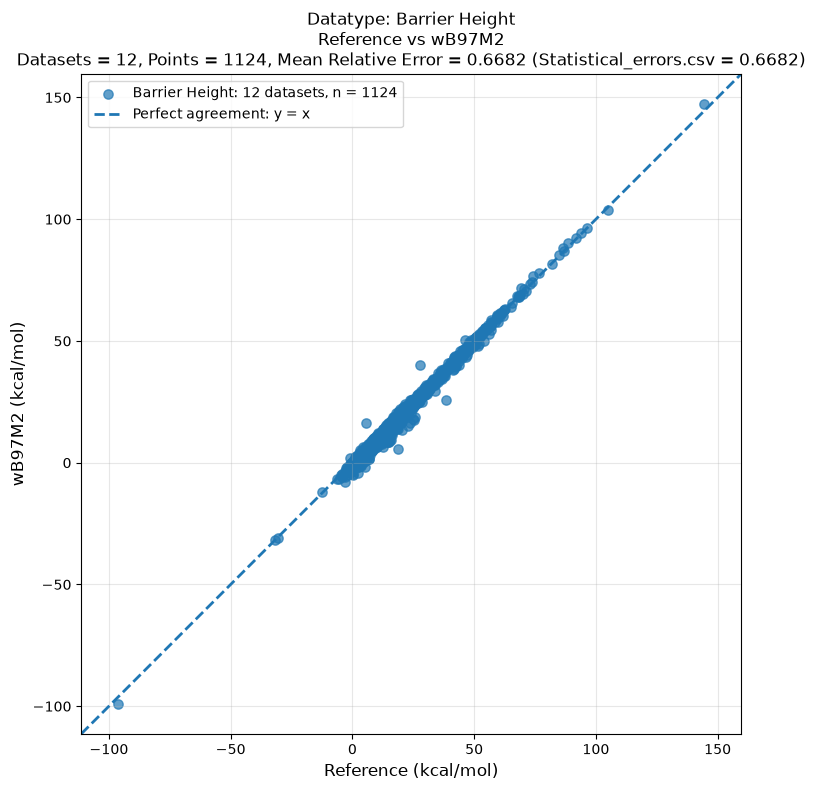

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Change only these two values
DATATYPE = "Barrier Height"
FUNCTIONAL = "wB97M2"

# Load files
results = pd.read_csv("Results_values.csv")
datasets_info = pd.read_csv(r"..\Info\Datasets.csv")
relative_errors = pd.read_csv("Relative_metric_per_set.csv")
statistical_errors = pd.read_csv(
    "Statistical_errors.csv",
    index_col=0
)

# Find all datasets belonging to the selected Datatype
datasets = datasets_info.loc[
    datasets_info["Datatype"] == DATATYPE,
    "Name"
].tolist()

# Select all Reference and functional values for the Datatype
selected = results.loc[
    results["Dataset"].isin(datasets),
    ["Reference", FUNCTIONAL]
].dropna()

x = selected["Reference"].to_numpy()
y = selected[FUNCTIONAL].to_numpy()

# Mean Relative Error = mean of dataset-level NER values
mre = relative_errors.loc[
    relative_errors["Dataset"].isin(datasets),
    FUNCTIONAL
].mean()

# Stored datatype MRE
mre_from_file = statistical_errors.loc[
    f"Mean {DATATYPE}",
    FUNCTIONAL
]

# Pooled correlation statistics
rmse = np.sqrt(np.mean((y - x) ** 2))
mae = np.mean(np.abs(y - x))
pearson_r = np.corrcoef(x, y)[0, 1]

print(f"Datatype: {DATATYPE}")
print(f"Functional: {FUNCTIONAL}")
print(f"Datasets: {len(datasets)}")
print(f"Data points: {len(selected)}")
print(f"Pooled RMSE: {rmse:.10f}")
print(f"Pooled MAE: {mae:.10f}")
print(f"Pearson r: {pearson_r:.10f}")
print(f"Calculated Mean Relative Error: {mre:.10f}")
print(
    "Mean Relative Error from Statistical_errors.csv: "
    f"{mre_from_file:.10f}"
)
print(
    f"MRE values match: "
    f"{np.isclose(mre, mre_from_file)}"
)

# Equal x-axis and y-axis ranges
minimum = min(x.min(), y.min())
maximum = max(x.max(), y.max())

padding = (
    0.05 * (maximum - minimum)
    if maximum > minimum
    else 1
)

plot_min = minimum - padding
plot_max = maximum + padding

energy_types = {
    "Barrier Height",
    "Intramolecular Noncovalent",
    "Isomerization",
    "Noncovalent",
    "Thermochemistry",
    "Transition Metal"
}

unit = (
    "kcal/mol"
    if DATATYPE in energy_types
    else "cm⁻¹"
    if DATATYPE == "Frequency"
    else "dataset-specific units"
)

# Correlation plot
plt.figure(figsize=(9, 8))

plt.scatter(
    x,
    y,
    s=45,
    alpha=0.7,
    label=(
        f"{DATATYPE}: {len(datasets)} datasets, "
        f"n = {len(selected)}"
    )
)

plt.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--",
    linewidth=2,
    label="Perfect agreement: y = x"
)

plt.xlim(plot_min, plot_max)
plt.ylim(plot_min, plot_max)

plt.gca().set_aspect(
    "equal",
    adjustable="box"
)

plt.xlabel(
    f"Reference ({unit})",
    fontsize=12
)

plt.ylabel(
    f"{FUNCTIONAL} ({unit})",
    fontsize=12
)

plt.title(
    f"Datatype: {DATATYPE}\n"
    f"Reference vs {FUNCTIONAL}\n"
    f"Datasets = {len(datasets)}, "
    f"Points = {len(selected)}, "
    f"Mean Relative Error = {mre:.4f} "
    f"(Statistical_errors.csv = "
    f"{mre_from_file:.4f})",
    fontsize=12
)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()